## Домашняя работа "Временные ряды, общая теория"

### Задание

Проанализируйте 6 временных рядов из папки Series и сделайте их стационарными:
- monthly-sales-of-company-x-jan-6.csv
- monthly-boston-armed-robberies-j.csv
- international-airline-passengers.csv
- mean-monthly-air-temperature-deg.csv
- weekly-closings-of-the-dowjones-.csv
- daily-total-female-births-in-cal.csv

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller

from scipy.stats import boxcox
from sklearn.preprocessing import power_transform

%matplotlib inline

In [98]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', 'Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

def test_and_show(y, title, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (4, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        
        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title(title)
        
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        acf_ax.set_title('{}. Autocorrelation'.format(title))

        plt.tight_layout()
    return

### Monthly sales

In [99]:
series1 = pd.read_csv("Series/monthly-sales-of-company-x-jan-6.csv")['Count']

Results of Dickey-Fuller Test:
Test Statistic                  0.654715
p-value                         0.988889
Lags Used                      12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


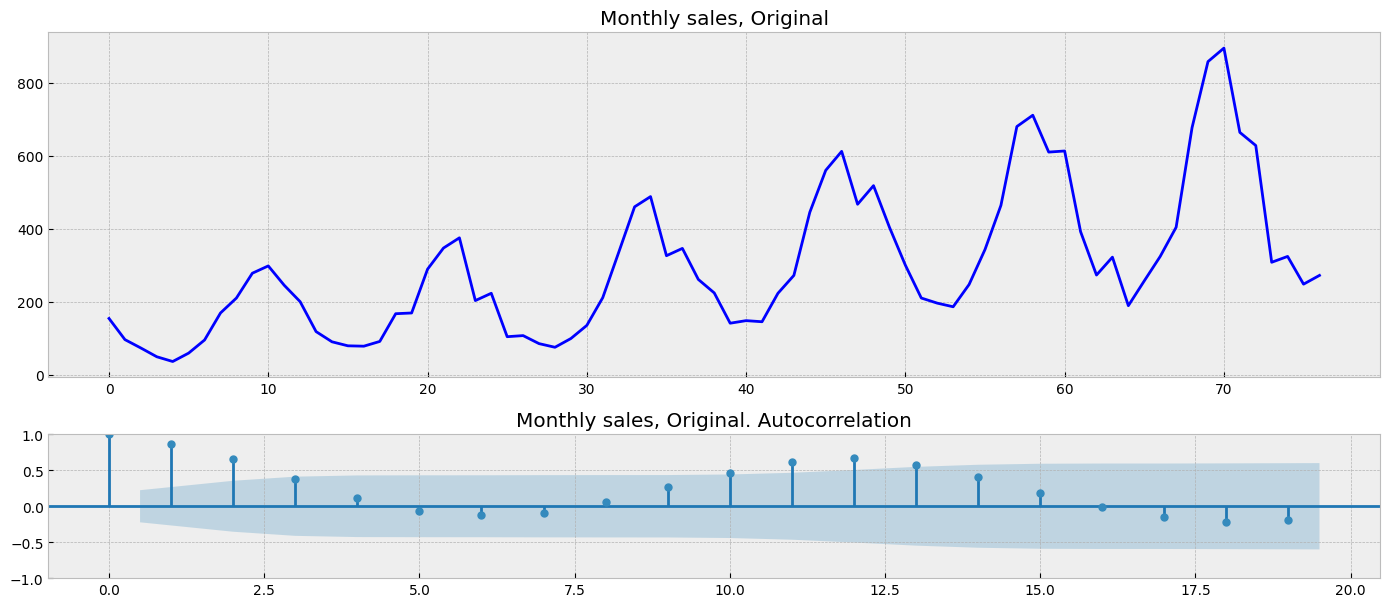

In [100]:
test_and_show(series1, "Monthly sales, Original")

#### Применим преобразование Бокса-Кокса

Results of Dickey-Fuller Test:
Test Statistic                 -0.908049
p-value                         0.785310
Lags Used                      12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


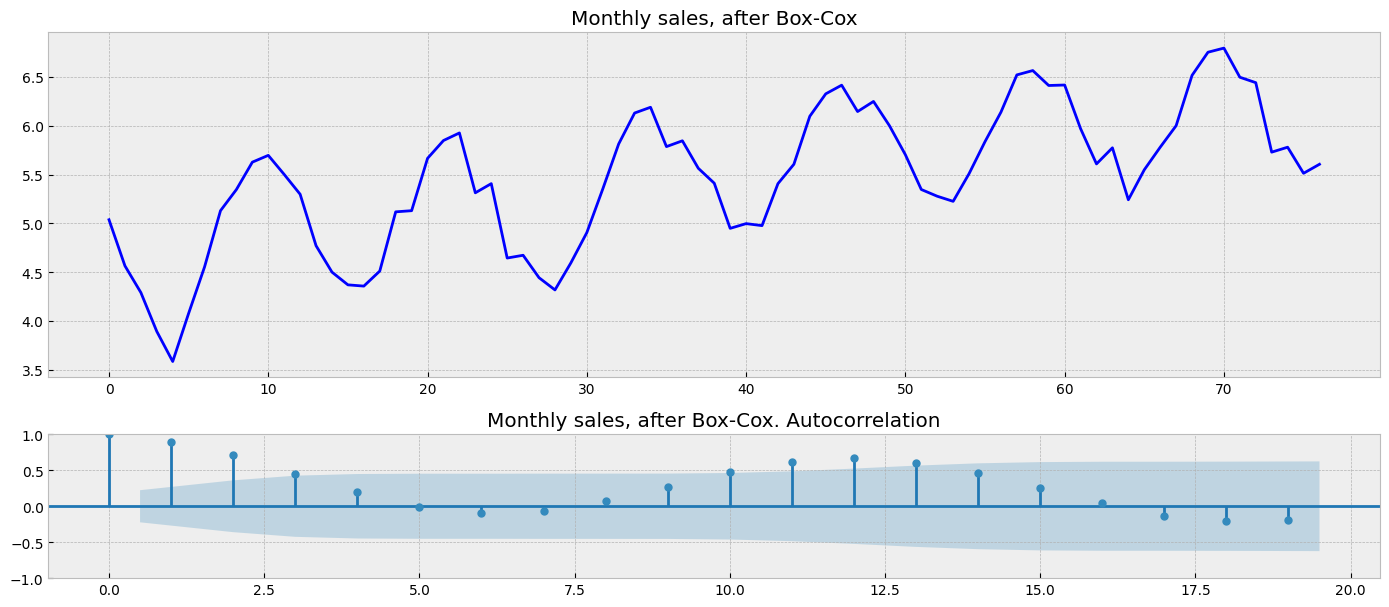

In [101]:
series1 = boxcox(series1, 0)
# Попробуем метод из библиотеки sklearn
#series1 = power_transform(series1, method='box-cox', standardize=False)

test_and_show(series1, "Monthly sales, after Box-Cox")

#### Применим дифференцирование

Results of Dickey-Fuller Test:
Test Statistic                 -3.135644
p-value                         0.024025
Lags Used                      11.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


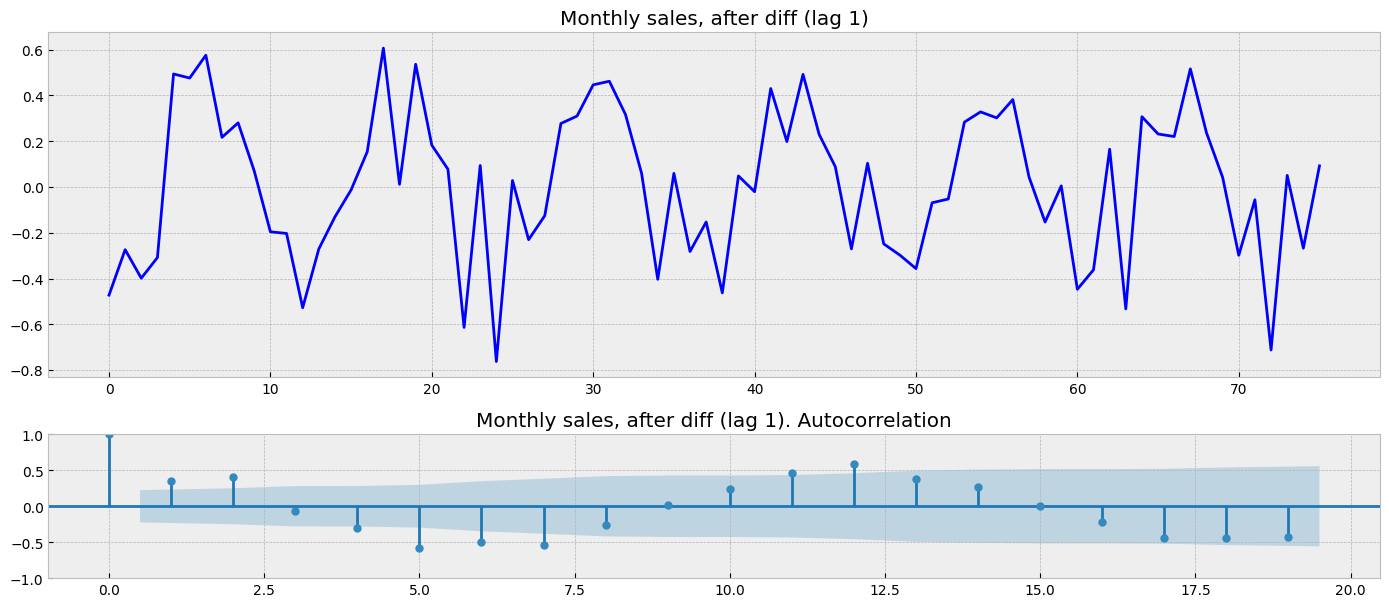

In [102]:
series1 = series1[1:] - series1[:-1]
test_and_show(series1, "Monthly sales, after diff (lag 1)")

### International airline passengers

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
Lags Used                       13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


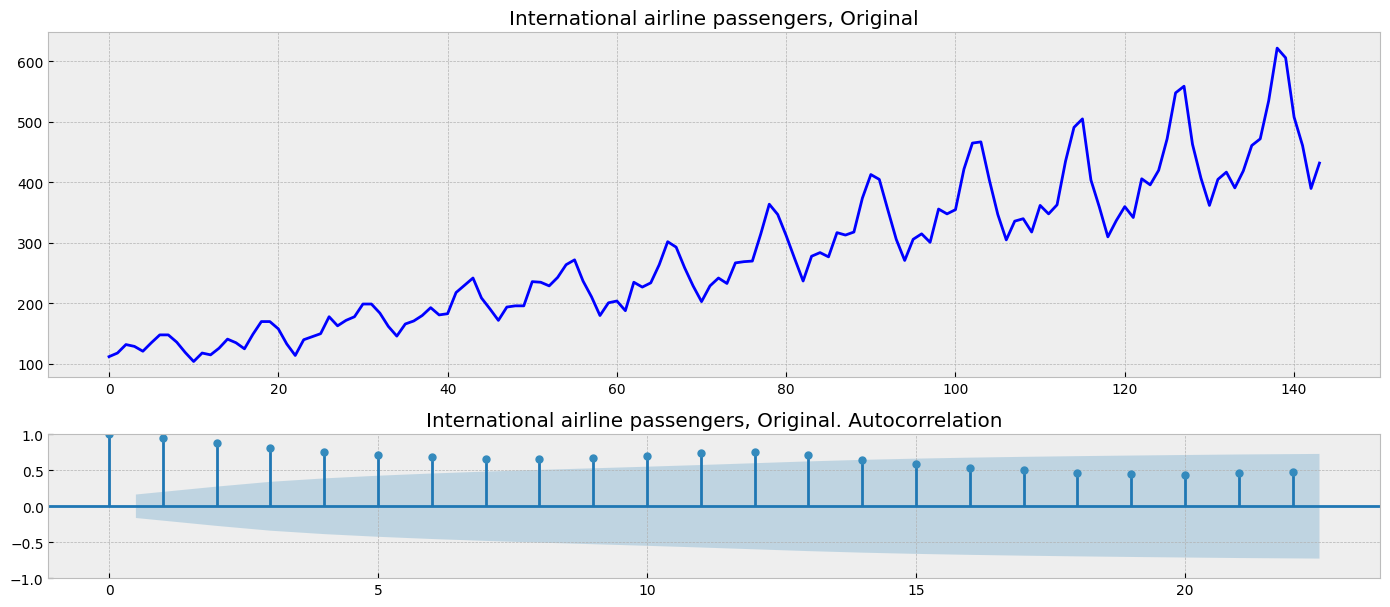

In [103]:
series2 = pd.read_csv("Series/international-airline-passengers.csv")['Count']

test_and_show(series2, "International airline passengers, Original")

#### Применим преобразование Бокса-Кокса

Results of Dickey-Fuller Test:
Test Statistic                  -1.717017
p-value                          0.422367
Lags Used                       13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


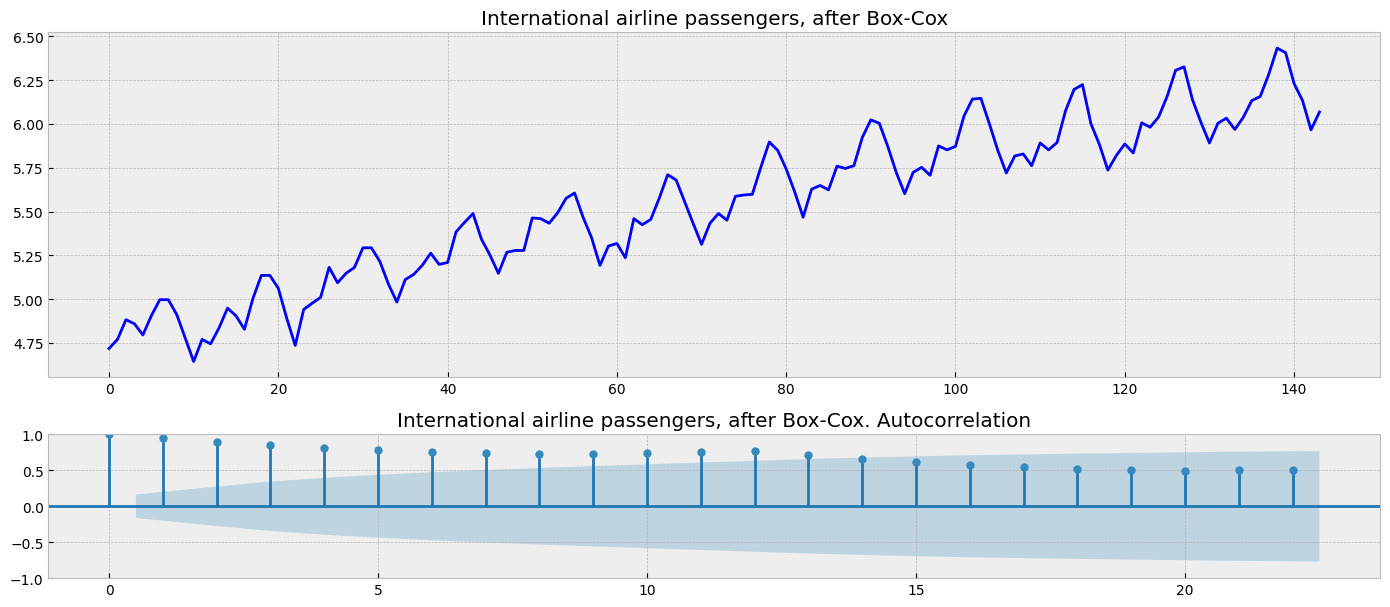

In [104]:
series2 = boxcox(series2, 0)
test_and_show(series2, "International airline passengers, after Box-Cox")

#### Применим дифференцирование

Results of Dickey-Fuller Test:
Test Statistic                  -2.717131
p-value                          0.071121
Lags Used                       14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


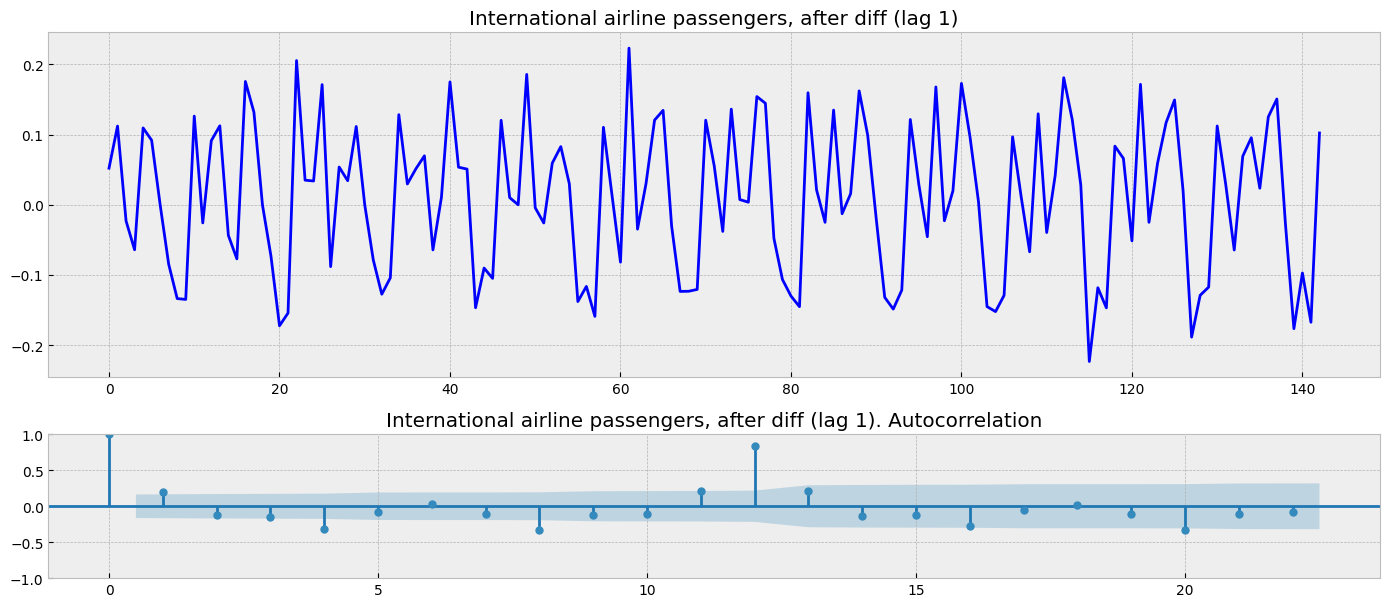

In [105]:
series2 = series2[1:] - series2[:-1]
test_and_show(series2, "International airline passengers, after diff (lag 1)")

#### Применим дифференцирование с лагом 12

Results of Dickey-Fuller Test:
Test Statistic                  -4.443325
p-value                          0.000249
Lags Used                       12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64


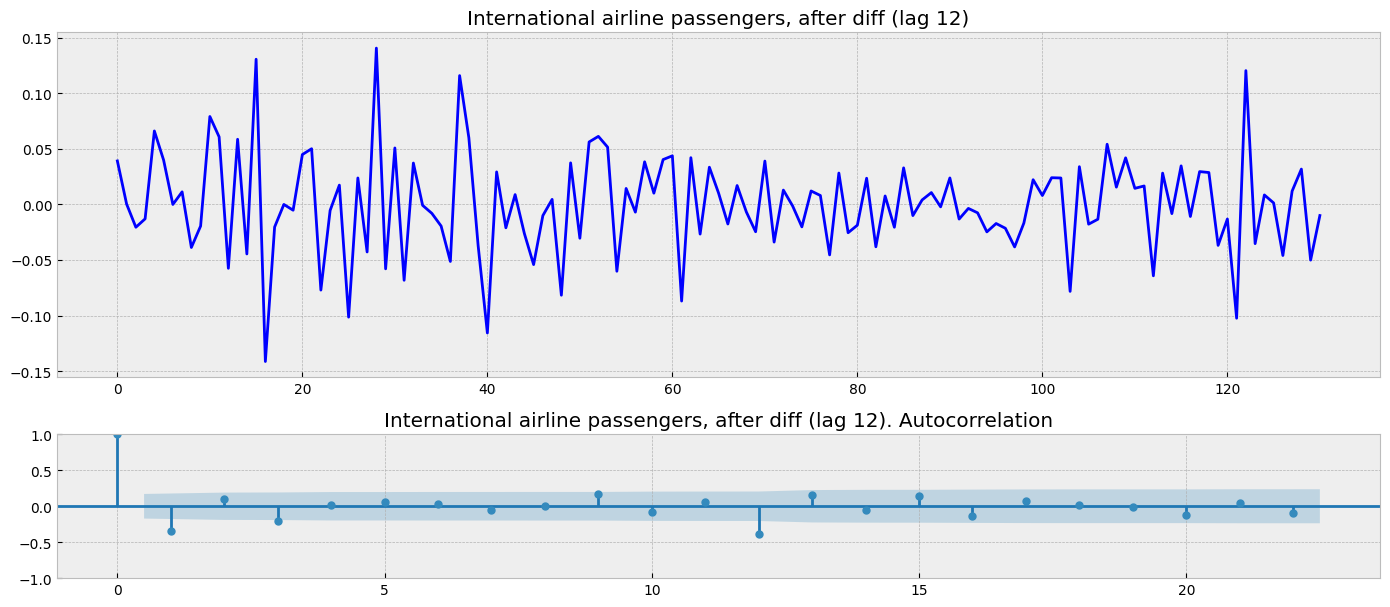

In [106]:
series2 = series2[12:] - series2[:-12]
test_and_show(series2, "International airline passengers, after diff (lag 12)")

### Mean monthly air temperature

Results of Dickey-Fuller Test:
Test Statistic                  -3.255492
p-value                          0.016989
Lags Used                       14.000000
Number of Observations Used    225.000000
Critical Value (1%)             -3.459752
Critical Value (5%)             -2.874473
Critical Value (10%)            -2.573663
dtype: float64


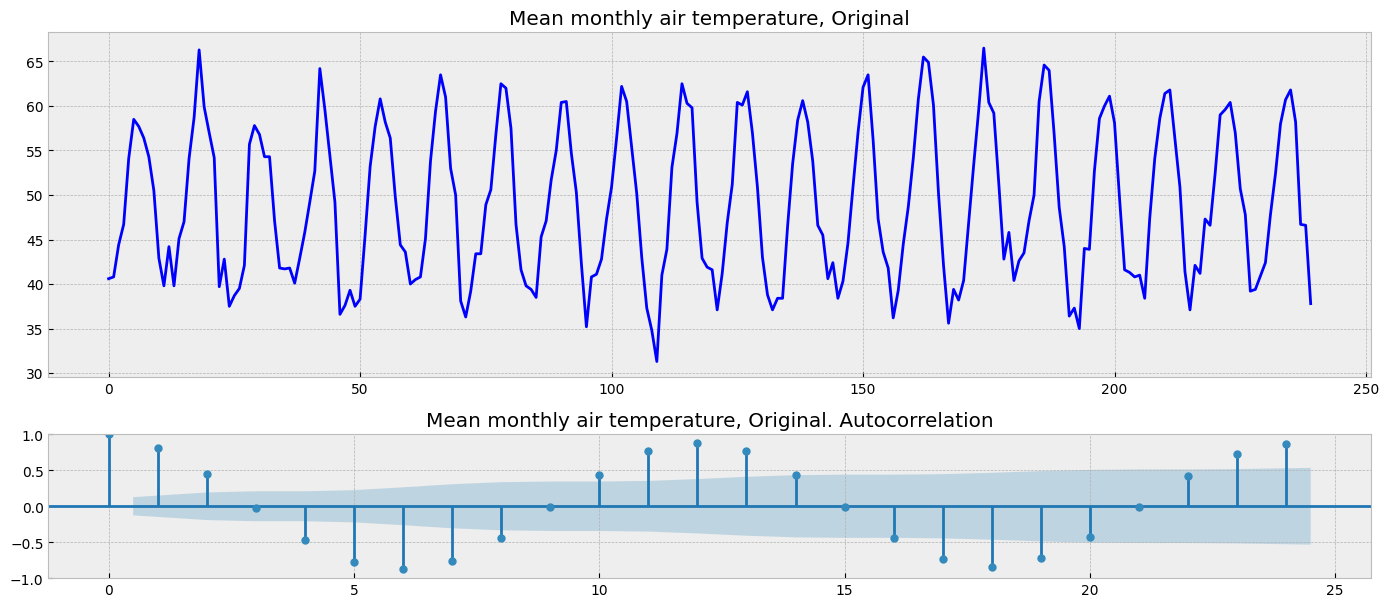

In [107]:
series3 = pd.read_csv("Series\mean-monthly-air-temperature-deg.csv")['Deg']
test_and_show(series3, "Mean monthly air temperature, Original")

#### Применим дифференцирование с лагом 12

Results of Dickey-Fuller Test:
Test Statistic                -6.072501e+00
p-value                        1.141945e-07
Lags Used                      1.200000e+01
Number of Observations Used    2.150000e+02
Critical Value (1%)           -3.461136e+00
Critical Value (5%)           -2.875079e+00
Critical Value (10%)          -2.573986e+00
dtype: float64


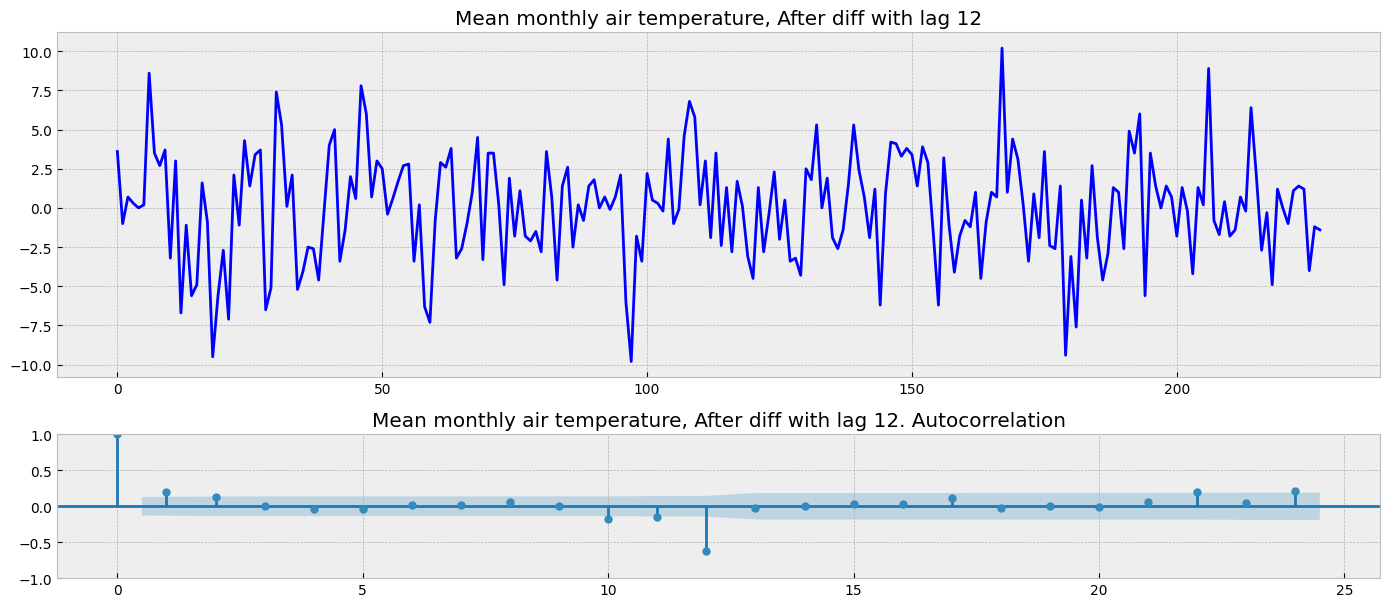

In [108]:
series3 = series3[12:].to_numpy() - series3[:-12].to_numpy()
test_and_show(series3, "Mean monthly air temperature, After diff with lag 12")

### Boston robberies

Results of Dickey-Fuller Test:
Test Statistic                   1.001102
p-value                          0.994278
Lags Used                       11.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64


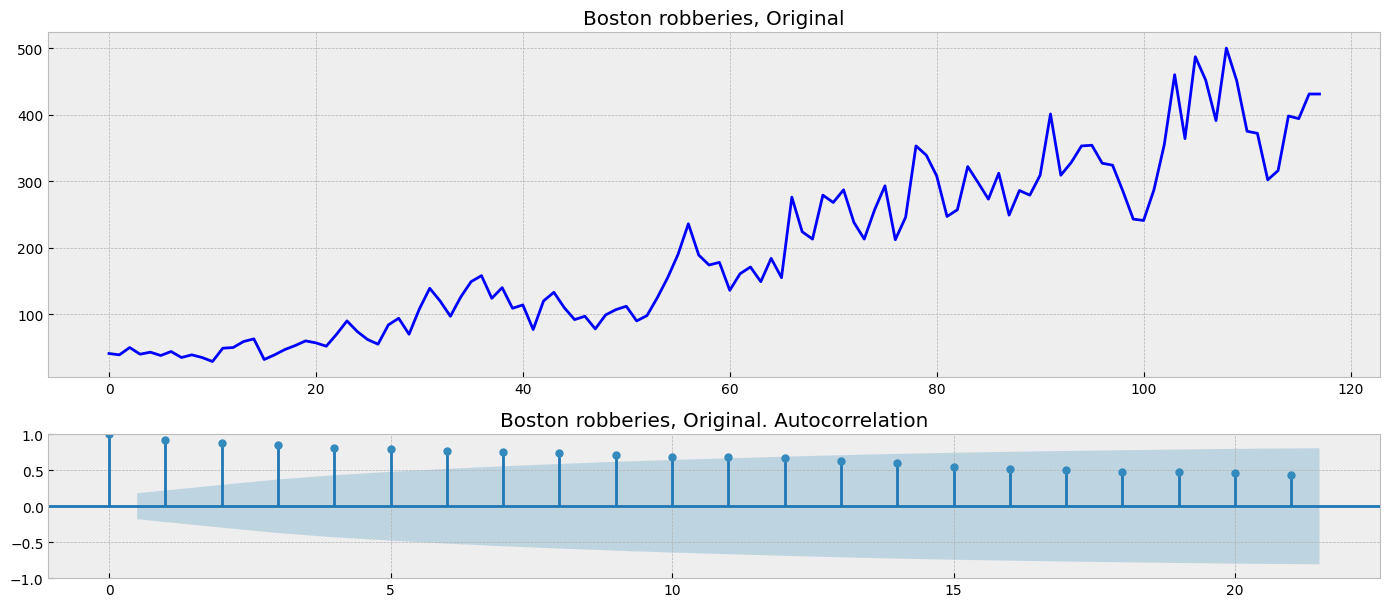

In [109]:
series4 = pd.read_csv('Series\monthly-boston-armed-robberies-j.csv')["Count"]
test_and_show(series4, "Boston robberies, Original")

#### Применим преобразование Бокса-Кокса

Results of Dickey-Fuller Test:
Test Statistic                  -2.013161
p-value                          0.280833
Lags Used                       10.000000
Number of Observations Used    107.000000
Critical Value (1%)             -3.492996
Critical Value (5%)             -2.888955
Critical Value (10%)            -2.581393
dtype: float64


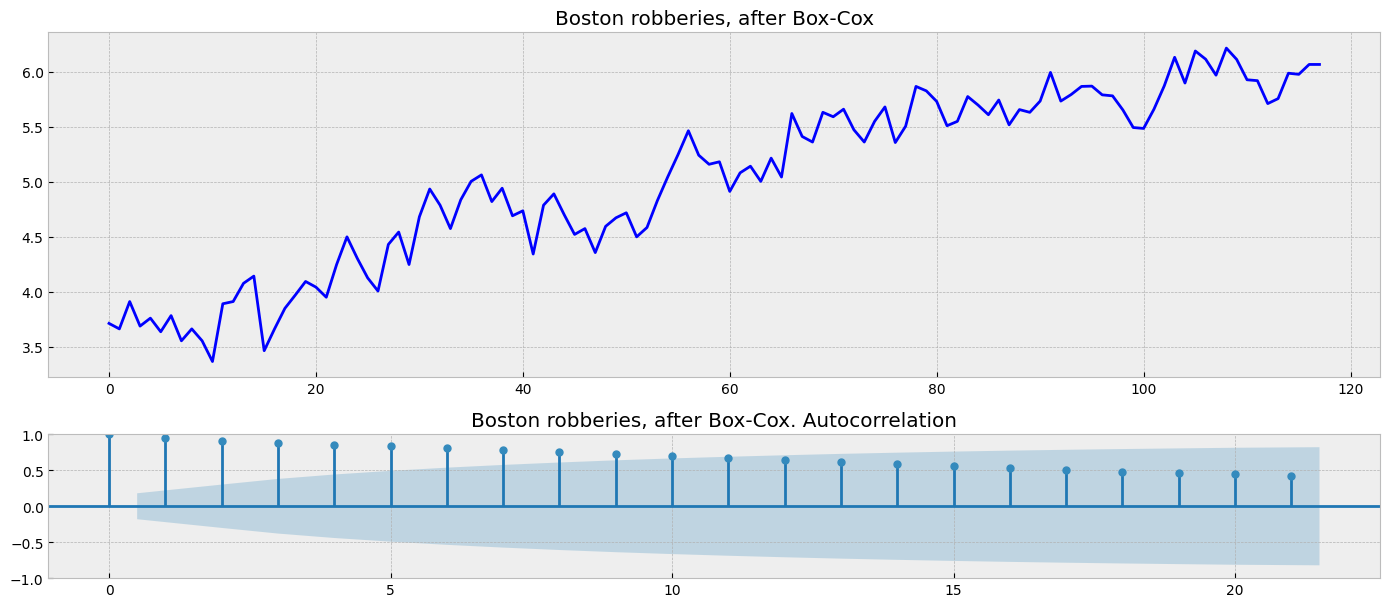

In [110]:
series4 = boxcox(series4, 0)
test_and_show(series4, "Boston robberies, after Box-Cox")

#### Применим дифференцирование, чтобы убрать тренд

Results of Dickey-Fuller Test:
Test Statistic                -7.601792e+00
p-value                        2.378602e-11
Lags Used                      3.000000e+00
Number of Observations Used    1.130000e+02
Critical Value (1%)           -3.489590e+00
Critical Value (5%)           -2.887477e+00
Critical Value (10%)          -2.580604e+00
dtype: float64


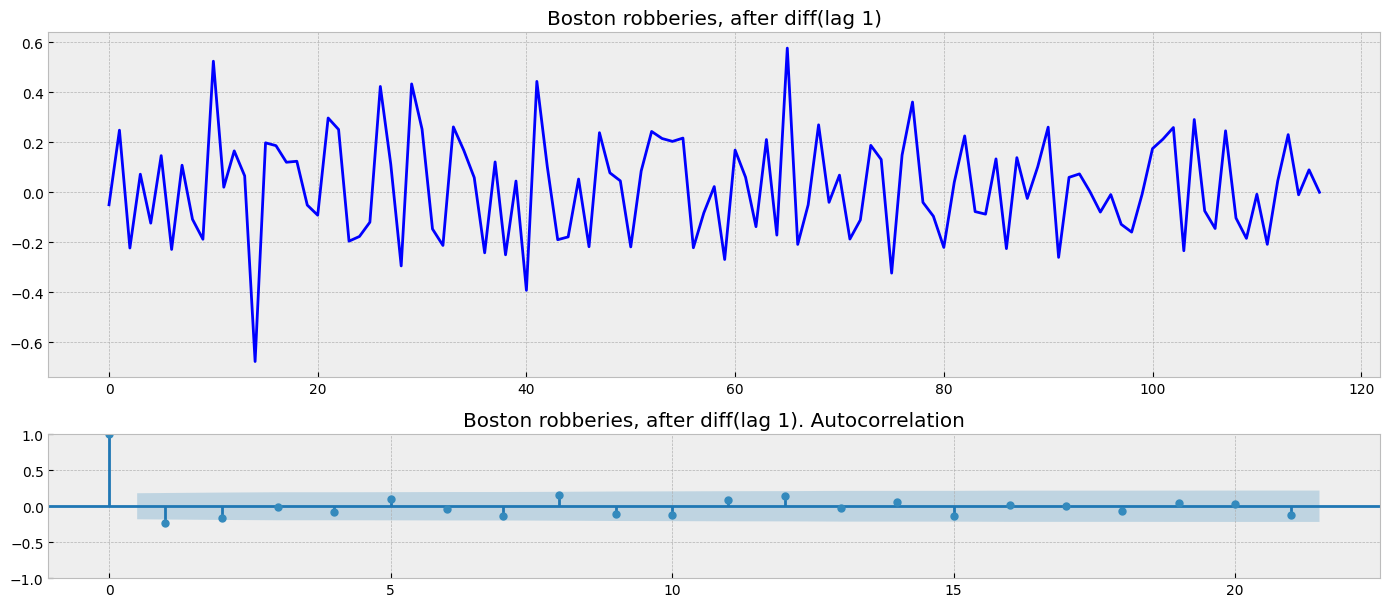

In [111]:
series4 = series4[1:] - series4[:-1]
test_and_show(series4, "Boston robberies, after diff(lag 1)")

### Daily total female births

Results of Dickey-Fuller Test:
Test Statistic                  -4.808291
p-value                          0.000052
Lags Used                        6.000000
Number of Observations Used    358.000000
Critical Value (1%)             -3.448749
Critical Value (5%)             -2.869647
Critical Value (10%)            -2.571089
dtype: float64


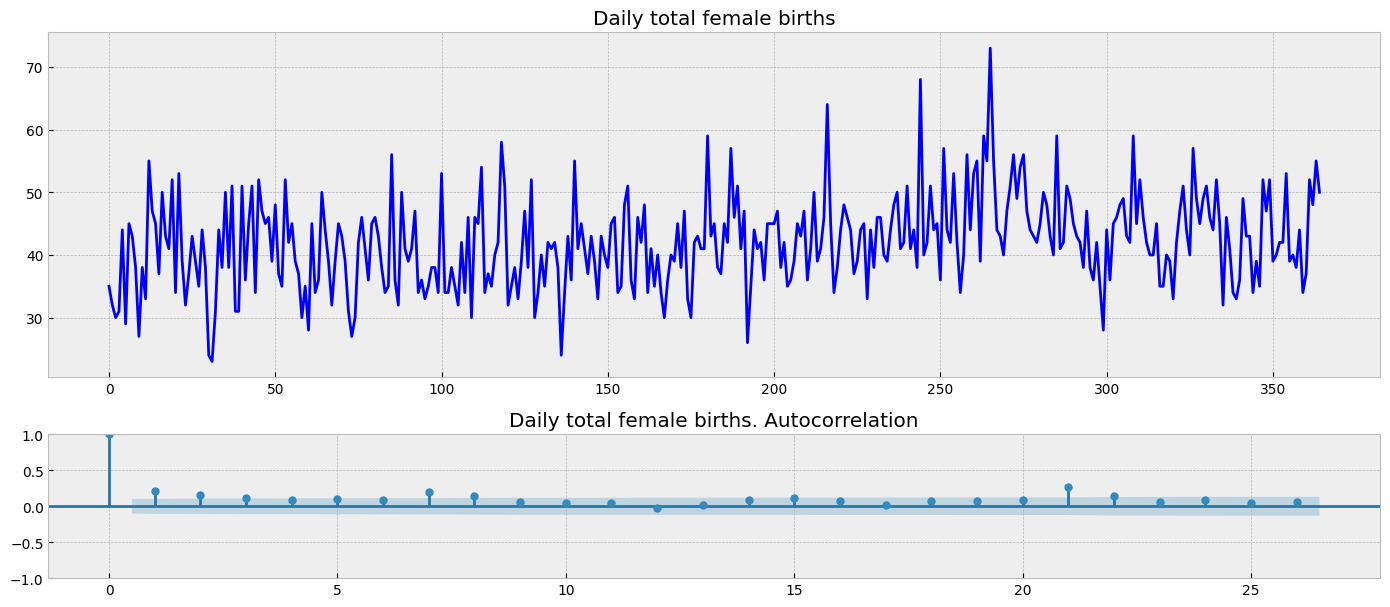

In [112]:
series5 = pd.read_csv('Series\daily-total-female-births-in-cal.csv')['Count']
test_and_show(series5, 'Daily total female births')

### Weekly closings of the dowjones

Results of Dickey-Fuller Test:
Test Statistic                  -1.314625
p-value                          0.622455
Lags Used                        0.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434
dtype: float64


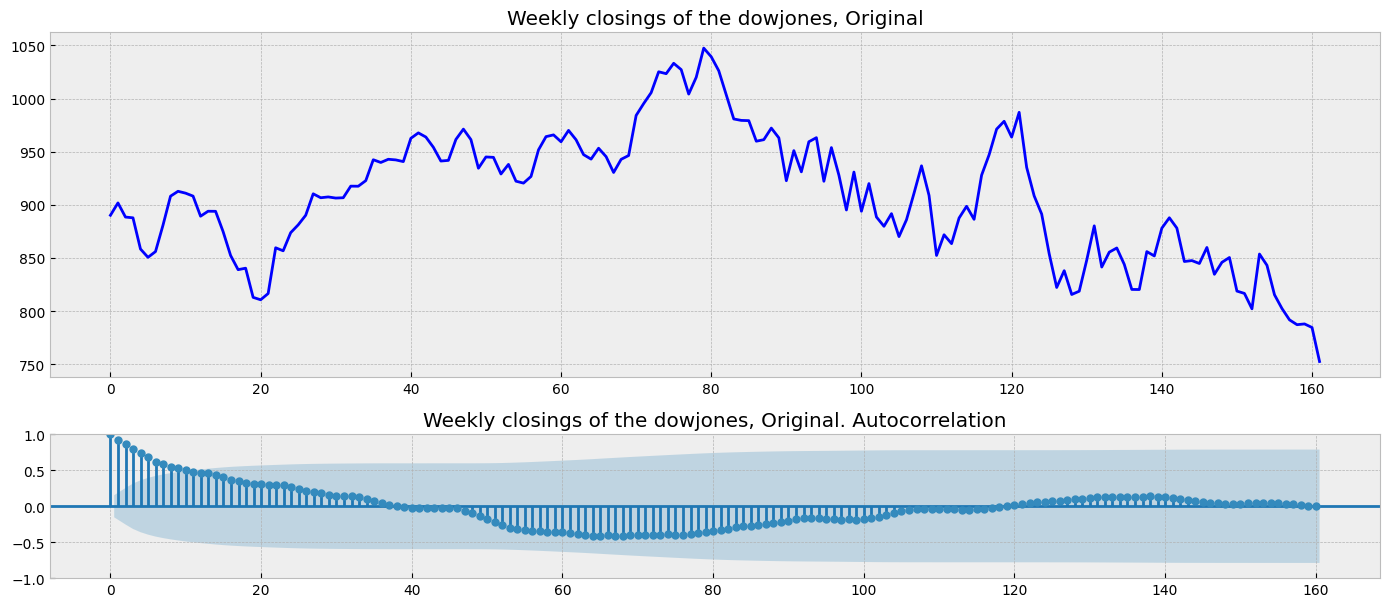

In [113]:
series6 = pd.read_csv('Series\weekly-closings-of-the-dowjones-.csv')['Close']
test_and_show(series6, 'Weekly closings of the dowjones, Original', lags=160)

#### Применим дифференцирование

Results of Dickey-Fuller Test:
Test Statistic                -1.302521e+01
p-value                        2.407586e-24
Lags Used                      0.000000e+00
Number of Observations Used    1.600000e+02
Critical Value (1%)           -3.471896e+00
Critical Value (5%)           -2.879780e+00
Critical Value (10%)          -2.576495e+00
dtype: float64


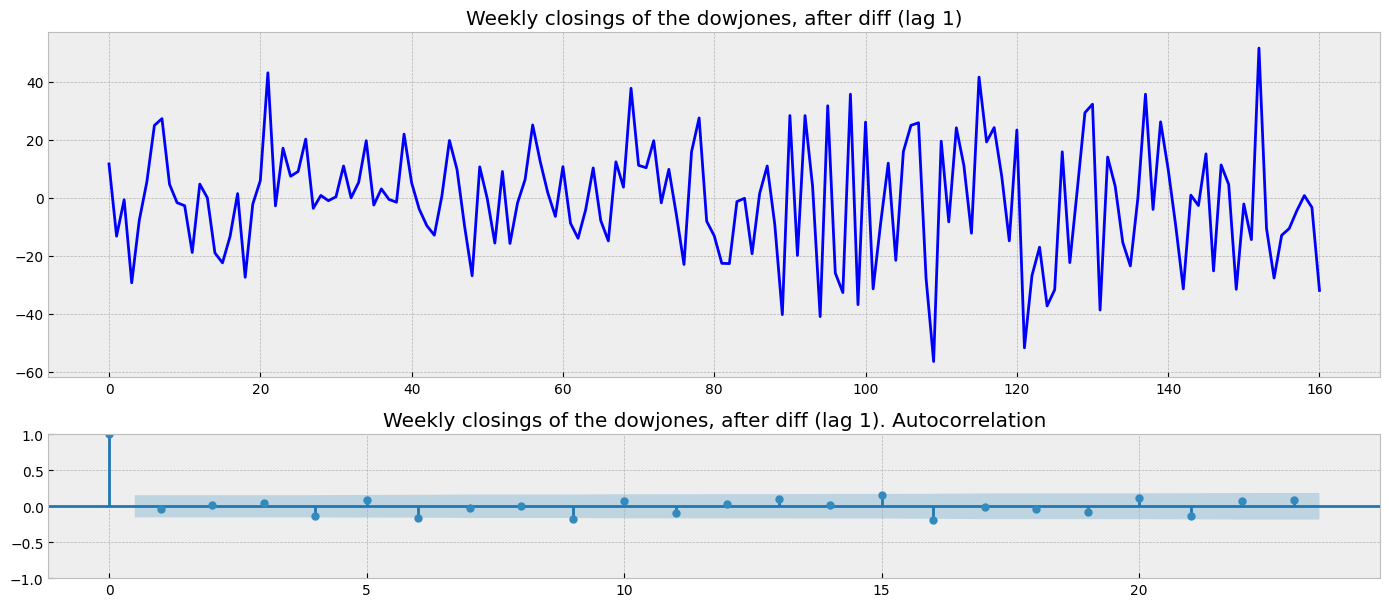

In [114]:
series6 = series6[1:].to_numpy()-series6[:-1].to_numpy()
test_and_show(series6, 'Weekly closings of the dowjones, after diff (lag 1)')